In [1]:
import xarray as xr

ds = xr.open_dataset('/data/SO3/edavenport/tpose6/oisst_data/oisst_equatorial_pacific_1993to2012.nc')

In [2]:
ds

<xarray.Dataset> Size: 842MB
Dimensions:    (time: 7305, latitude: 80, longitude: 360)
Coordinates:
  * time       (time) datetime64[ns] 58kB 1993-01-01T12:00:00 ... 2012-12-31T...
  * latitude   (latitude) float32 320B -9.875 -9.625 -9.375 ... 9.625 9.875
  * longitude  (longitude) float32 1kB -179.9 -179.6 -179.4 ... -90.38 -90.12
Data variables:
    sst        (time, latitude, longitude) float32 842MB ...

In [3]:
monthly_mean = ds.sst.groupby('time.month').mean('time')

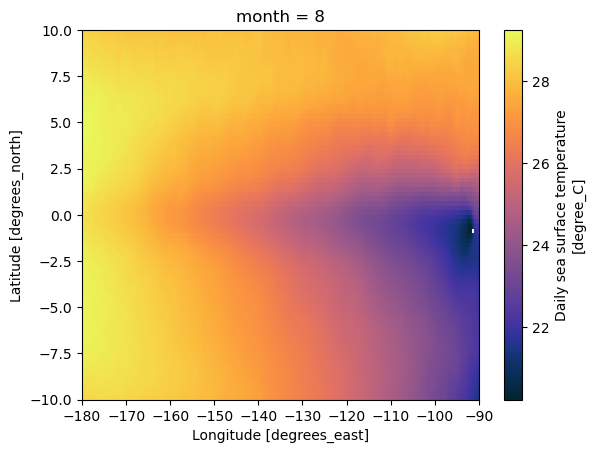

In [4]:
import cmocean.cm as cmo
monthly_mean.sel(month=8).plot(x='longitude', cmap=cmo.thermal)

In [5]:
climatological_std = ds.sst.groupby('time.month').std('time')

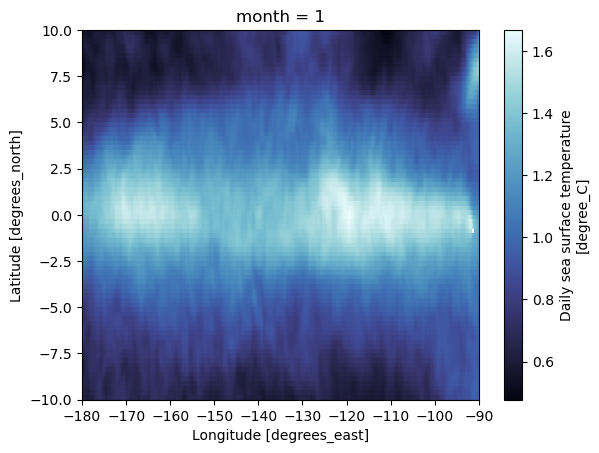

In [6]:
climatological_std.sel(month=1).plot(x='longitude', cmap=cmo.ice)

In [7]:
ds_stats = xr.Dataset({
    'sst_mean': monthly_mean,
    'sst_std':  climatological_std,
})
ds_stats.to_netcdf('forecasts/oisst_data/oisst_climatology_1993to2012.nc')